<a href="https://colab.research.google.com/github/sudikshyapant/unet/blob/main/unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as f
from torchvision import datasets, transforms
import torchvision.datasets.oxford_iiit_pet as Data
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device:{device}')

Using device:cuda


## Load Dataset

In [2]:
IMG_SIZE = 256
BATCH_SIZE = 8

img_transform = transforms.Compose([
 transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
 transforms.ToTensor(),
 transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

mask_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor()
])

train_set = datasets.OxfordIIITPet(
    root='data',
    split='trainval',
    target_types='segmentation',
    download=True,
    transform=img_transform,
    target_transform=mask_transform,
)

test_set = datasets.OxfordIIITPet(
    root='data',
    split='test',
    target_types='segmentation',
    transform=img_transform,
    target_transform=mask_transform,
    download=True
)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

print(f'Train samples: {len(train_set)} | Test samples: {len(test_set)}')


100%|██████████| 792M/792M [00:03<00:00, 238MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 131MB/s] 


Train samples: 3680 | Test samples: 3669


## The Model

In [3]:
class Encoder(nn.Module):
  def __init__(self, in_channels, num_filters):
    super().__init__()
    self.block = nn.Sequential(
        nn.Conv2d(in_channels, num_filters, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(num_filters, num_filters, kernel_size=3, padding=1),
        nn.ReLU()
    )

    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

  def forward(self, x):
      features = self.block(x)
      pooled = self.pool(features)
      return pooled, features



class Decoder(nn.Module):
    def __init__(self, in_channels, num_filters):
      super().__init__()

      self.upsample = nn.ConvTranspose2d(in_channels, num_filters, kernel_size=2, stride=2)

      self.conv_block = nn.Sequential(
          # had used in_channel * 2 and padding = 0 (like the original paper)
          nn.Conv2d(num_filters * 2, num_filters, kernel_size=3, padding=1), # Corrected input channels to num_filters * 2
          nn.ReLU(),
          nn.Conv2d(num_filters, num_filters, kernel_size=3, padding=1),
          nn.ReLU(),
      )

    def forward(self, x, skip_features):
        x = self.upsample(x)
        skip = f.interpolate(skip_features, size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv_block(x)



class UNet(nn.Module):
  def __init__(self, in_channels=3, num_classes=1):
    super().__init__()

    # Contracting part
    self.enc1 = Encoder(in_channels, 64)
    self.enc2 = Encoder(64, 128)
    self.enc3 = Encoder(128, 256)
    self.enc4 = Encoder(256, 512)

    # Bottleneck
    self.bottleneck = nn.Sequential(
        nn.Conv2d(512, 1024, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
        nn.ReLU(),
    )

    # Decoder
    self.dec1 = Decoder(1024, 512)
    self.dec2 = Decoder(512, 256)
    self.dec3 = Decoder(256, 128)
    self.dec4 = Decoder(128, 64)

    # Final 1x1 conv
    self.final = nn.Conv2d(64, num_classes, kernel_size=1)

  def forward(self, x):
    # Encoder: colelct the skip connections
    x, s1 = self.enc1(x)
    x, s2 = self.enc2(x)
    x, s3 = self.enc3(x)
    x, s4 = self.enc4(x)

    x = self.bottleneck(x)

    x = self.dec1(x, s4)
    x = self.dec2(x, s3)
    x = self.dec3(x, s2)
    x = self.dec4(x, s1)

    return self.final(x)



NUM_CLASSES = 3
model = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 31,031,875


## Training and Evaluation Helpers


In [4]:
def preprocess_mask(mask):
  # removes channel information. converts dtype to long int. shifts back by 1.
  return mask.squeeze(1).long().to(device)-1

def train_one_epoch(model, loader, optimizer, criterion):
  model.train()
  running_loss = 0.0
  for imgs, masks in loader:
    imgs = imgs.to(device)
    masks = preprocess_mask(masks)

    logits = model(imgs)
    # do we need to resize the logits back to the mask resolution?
    logits = f.interpolate(logits, size=masks.shape[-2:], mode='bilinear', align_corners=False)

    loss = criterion(logits, masks)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  return running_loss/len(loader)


def evaluate(model, loader, criterion):
  model.eval()
  total_loss, correct, total = 0.0, 0, 0
  inter_sum = torch.zeros(NUM_CLASSES)
  union_sum = torch.zeros(NUM_CLASSES)

  with torch.no_grad():
    for imgs, masks in loader:
      imgs = imgs.to(device)
      masks = preprocess_mask(masks)

      logits = model(imgs)
      logits = f.interpolate(logits, size=masks.shape[-2:], mode='bilinear', align_corners=False)

      total_loss += criterion(logits, masks).item()

      preds = logits.argmax(dim=1)
      correct += (preds == masks).sum().item()
      total += masks.numel()

      for c in range(NUM_CLASSES):
        preds_c = (preds == c)
        target_c = (masks == c)
        inter_sum[c] += (preds_c & target_c).sum().item()
        union_sum[c] += (preds_c | target_c).sum().item()

  avg_loss = total_loss / len(loader)
  pixel_acc = correct / total
  # Global IoU: total intersection/total union per class, then average
  mean_iou = (inter_sum / (union_sum + 1e-6)).mean().item()
  return avg_loss, pixel_acc, mean_iou


## Train

In [5]:
NUM_EPOCHS = 10
# try and change lr = 1e-3  the default
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [],
           'val_loss': [],
           'pixel_acc': [],
           'mean_iou': []}

for epoch in range(1, NUM_EPOCHS+1):
  train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
  val_loss, acc, mean_iou = evaluate(model, test_loader, criterion)

  history['train_loss'].append(train_loss)
  history['val_loss'].append(val_loss)
  history['pixel_acc'].append(acc)
  history['mean_iou'].append(mean_iou)

  print(f'Epoch {epoch:2d}/{NUM_EPOCHS} | '
      f'Train Loss: {train_loss:.4f} | '
      f'Val Loss: {val_loss:.4f} | '
      f'Pixel Acc: {acc:.4f} | '
      f'Mean IoU: {mean_iou:.4f}')


Epoch  1/10 | Train Loss: 0.7994 | Val Loss: 0.7300 | Pixel Acc: 0.7066 | Mean IoU: 0.3774
Epoch  2/10 | Train Loss: 0.6798 | Val Loss: 0.6532 | Pixel Acc: 0.7362 | Mean IoU: 0.4472
Epoch  3/10 | Train Loss: 0.6211 | Val Loss: 0.5571 | Pixel Acc: 0.7819 | Mean IoU: 0.5247
Epoch  4/10 | Train Loss: 0.5269 | Val Loss: 0.4754 | Pixel Acc: 0.8129 | Mean IoU: 0.5783
Epoch  5/10 | Train Loss: 0.4506 | Val Loss: 0.4182 | Pixel Acc: 0.8384 | Mean IoU: 0.6218
Epoch  6/10 | Train Loss: 0.4070 | Val Loss: 0.3914 | Pixel Acc: 0.8483 | Mean IoU: 0.6468
Epoch  7/10 | Train Loss: 0.3726 | Val Loss: 0.3682 | Pixel Acc: 0.8598 | Mean IoU: 0.6683
Epoch  8/10 | Train Loss: 0.3501 | Val Loss: 0.3888 | Pixel Acc: 0.8525 | Mean IoU: 0.6438
Epoch  9/10 | Train Loss: 0.3325 | Val Loss: 0.3495 | Pixel Acc: 0.8696 | Mean IoU: 0.6862
Epoch 10/10 | Train Loss: 0.3093 | Val Loss: 0.3263 | Pixel Acc: 0.8758 | Mean IoU: 0.6929


## Training Curve

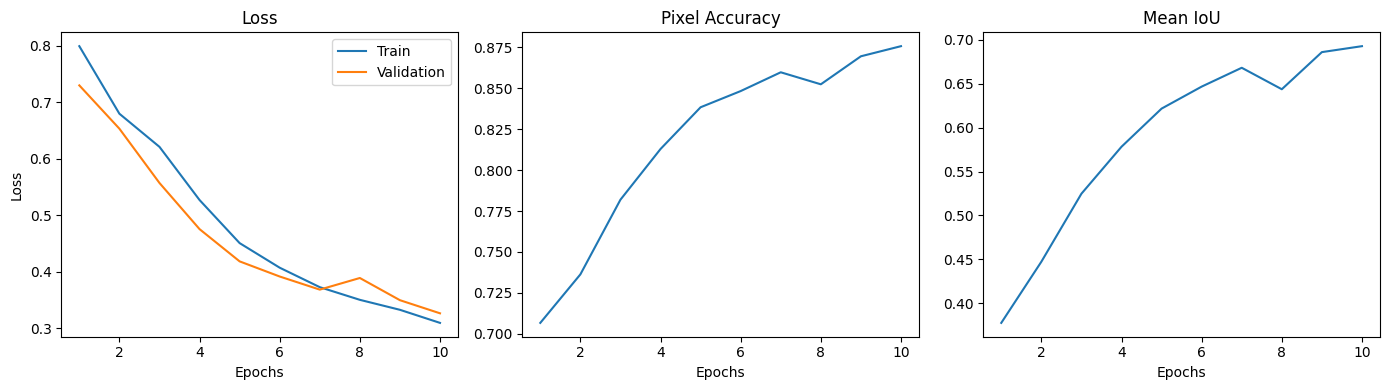

In [6]:
epochs = range(1, NUM_EPOCHS+1)

fig, axes = plt.subplots(1, 3, figsize=(14,4))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'], label='Validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(epochs, history['pixel_acc'])
axes[1].set_title('Pixel Accuracy'); axes[1].set_xlabel('Epochs');

axes[2].plot(epochs, history['mean_iou'])
axes[2].set_title('Mean IoU'); axes[2].set_xlabel('Epochs');

plt.tight_layout()
plt.show()

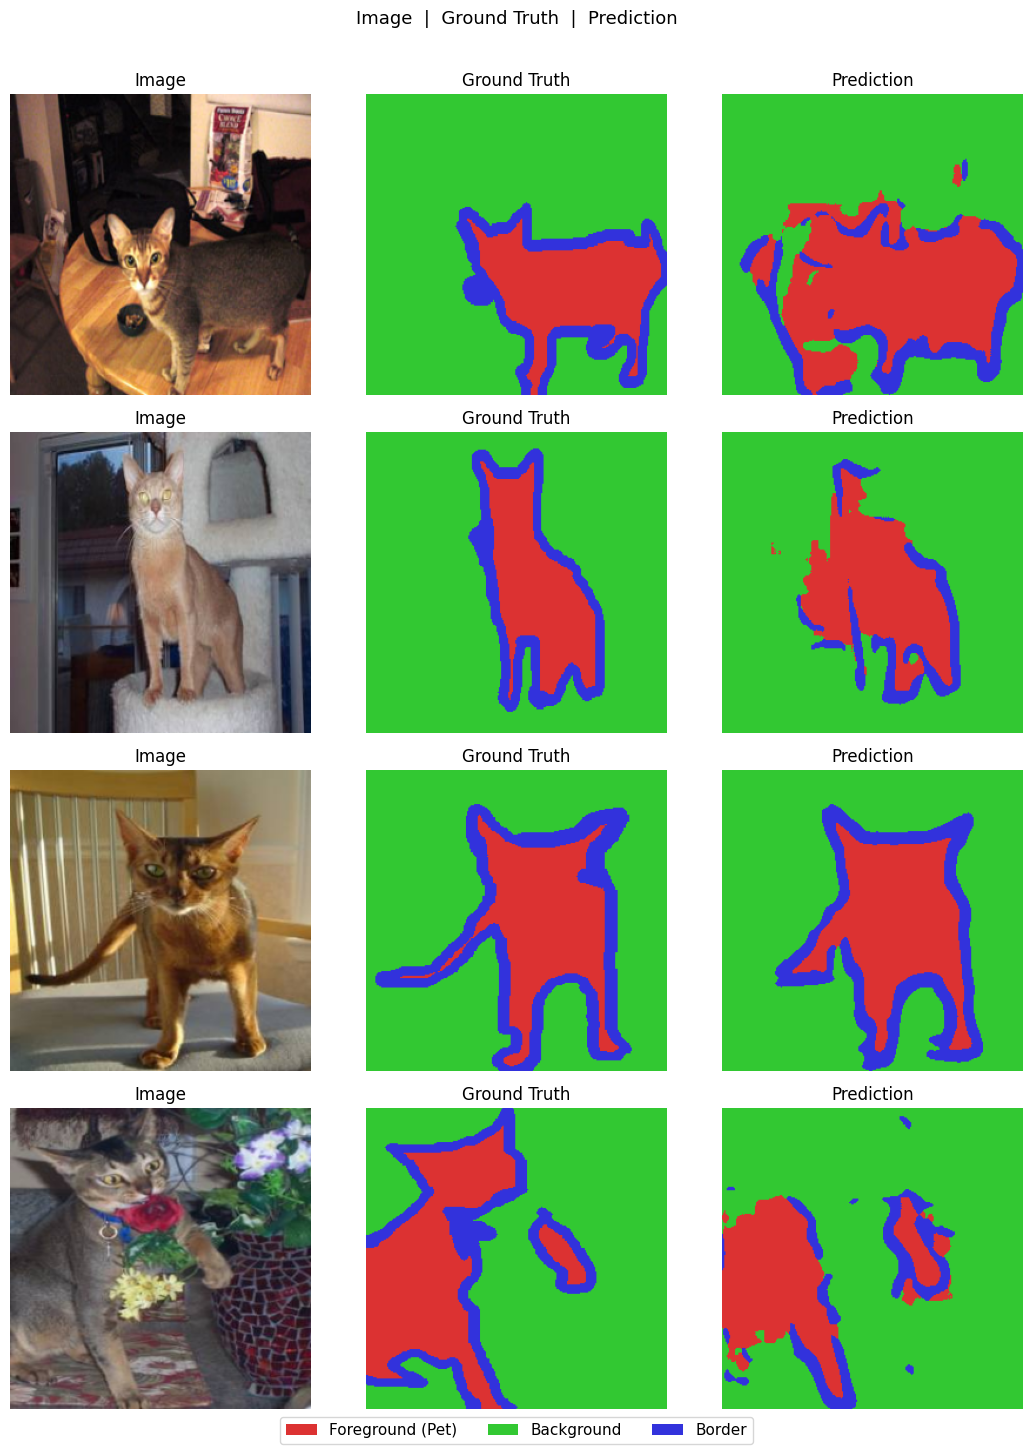

In [8]:
# Class colours: 0=foreground(red), 1=background(green), 2=border(blue)
CLASS_COLORS = np.array([[220, 50, 50], [50, 200, 50], [50, 50, 220]], dtype=np.uint8)
CLASS_LABELS = ['Foreground (Pet)', 'Background', 'Border']

def denormalize(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

def to_color_mask(mask_2d):
    """(H, W) int array with values 0/1/2 → (H, W, 3) RGB"""
    return CLASS_COLORS[mask_2d]


model.eval()
imgs, masks = next(iter(test_loader))
with torch.no_grad():
    logits = model(imgs.to(device))
    logits = f.interpolate(logits, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    preds  = logits.argmax(dim=1).cpu().numpy()   # (B, H, W)

gt = (masks.squeeze(1).long() - 1).numpy()        # (B, H, W)

N = 4   # number of samples to show
fig, axes = plt.subplots(N, 3, figsize=(11, N * 3.5))
fig.suptitle('Image  |  Ground Truth  |  Prediction', fontsize=13, y=1.01)

for i in range(N):
    axes[i, 0].imshow(denormalize(imgs[i]))
    axes[i, 0].set_title('Image');        axes[i, 0].axis('off')

    axes[i, 1].imshow(to_color_mask(gt[i]))
    axes[i, 1].set_title('Ground Truth'); axes[i, 1].axis('off')

    axes[i, 2].imshow(to_color_mask(preds[i]))
    axes[i, 2].set_title('Prediction');   axes[i, 2].axis('off')

# Legend
from matplotlib.patches import Patch
legend = [Patch(facecolor=np.array(c)/255, label=l) for c, l in zip(CLASS_COLORS, CLASS_LABELS)]
fig.legend(handles=legend, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=11)

plt.tight_layout()
plt.show()